In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

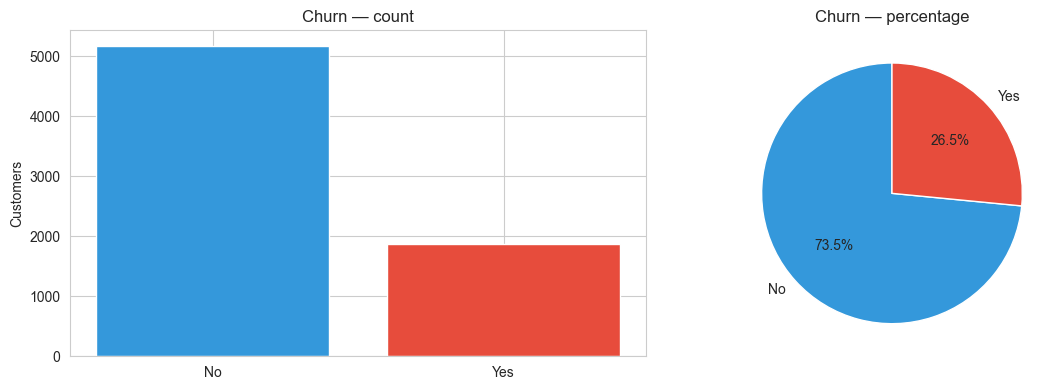

In [6]:
churn_counts = df["Churn"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=["#3498db", "#e74c3c"])
axes[0].set_title("Churn — count")
axes[0].set_ylabel("Customers")

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
            colors=["#3498db", "#e74c3c"], startangle=90)
axes[1].set_title("Churn — percentage")

plt.tight_layout()
plt.show()

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

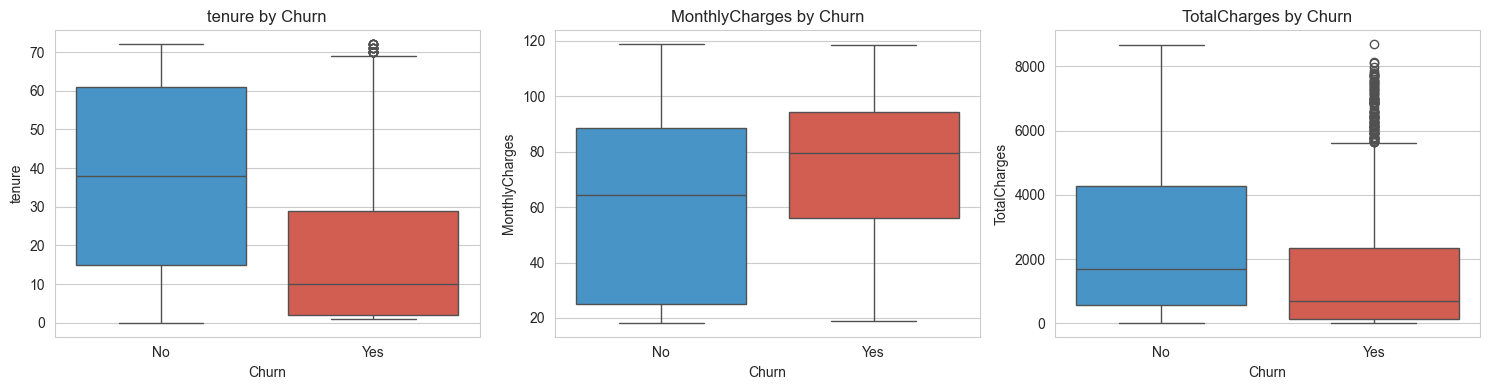

In [9]:
numerical = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical):
    sns.boxplot(x="Churn", y=col, data=df, ax=axes[i],
                palette=["#3498db", "#e74c3c"])
    axes[i].set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

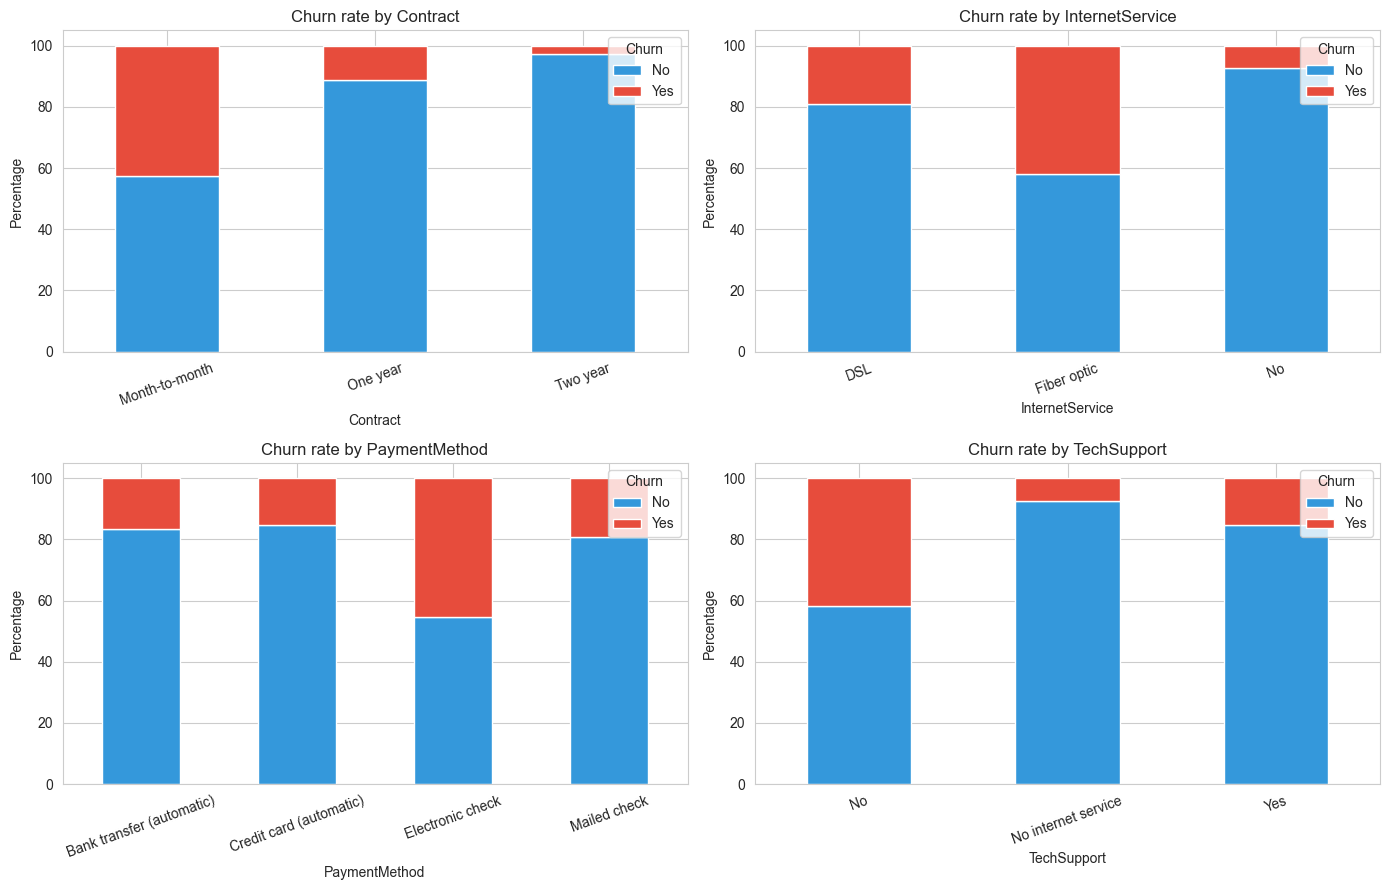

In [10]:
key_categoricals = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flatten(), key_categoricals):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=["#3498db", "#e74c3c"])
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Percentage")
    ax.legend(title="Churn", loc="upper right")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

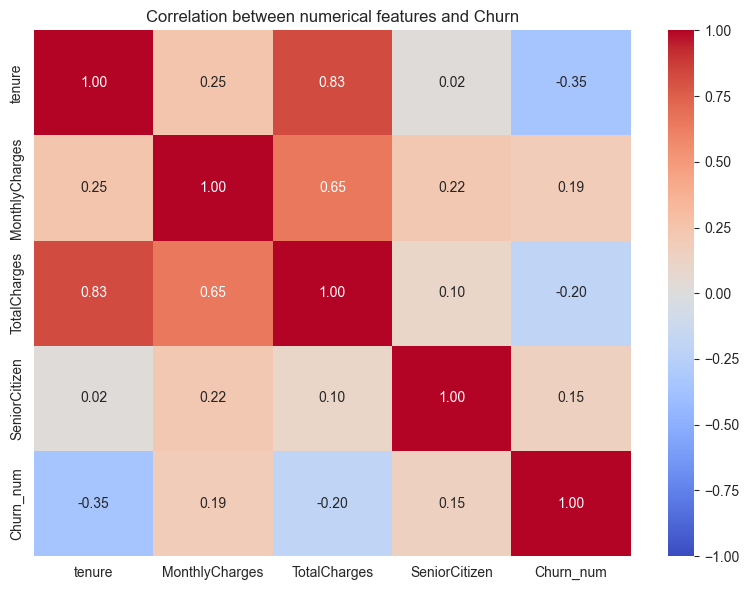

In [11]:
# Encode Churn temporarily so we can include it in the correlation
df_corr = df.copy()
df_corr["Churn_num"] = df_corr["Churn"].map({"No": 0, "Yes": 1})

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_num"]
corr = df_corr[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1)
plt.title("Correlation between numerical features and Churn")
plt.tight_layout()
plt.show()

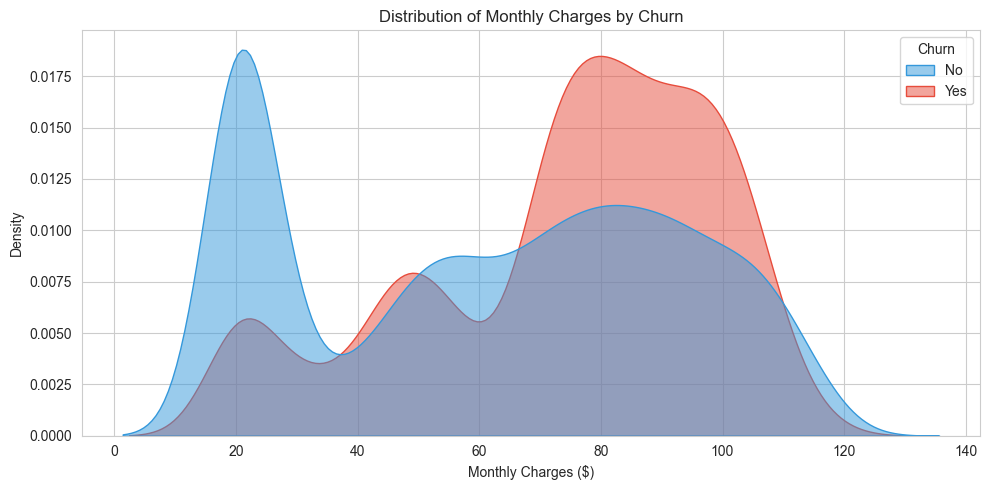

In [12]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn",
            fill=True, common_norm=False, alpha=0.5,
            palette=["#3498db", "#e74c3c"])
plt.title("Distribution of Monthly Charges by Churn")
plt.xlabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

In [13]:
# Drop the customerID column — it's just an identifier, useless for prediction
df = df.drop(columns=["customerID"])

# Fill the NaN values in TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")

Shape after cleaning: (7043, 20)
Missing values: 0


In [14]:
y = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")

X shape: (7043, 19)
y distribution: {0: 5174, 1: 1869}


In [15]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
print(f"  {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}):")
print(f"  {categorical_cols}")

Numerical columns (4):
  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (15):
  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

print("Preprocessor created:")
print(preprocessor)

Preprocessor created:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])


In [17]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train_raw.shape}")
print(f"X_test:  {X_test_raw.shape}")
print(f"\nTrain class balance: {dict(y_train.value_counts())}")
print(f"Test  class balance: {dict(y_test.value_counts())}")

X_train: (5634, 19)
X_test:  (1409, 19)

Train class balance: {0: np.int64(4139), 1: np.int64(1495)}
Test  class balance: {0: np.int64(1035), 1: np.int64(374)}


In [19]:

X_train = preprocessor.fit_transform(X_train_raw)


X_test = preprocessor.transform(X_test_raw)

print(f"X_train shape after preprocessing: {X_train.shape}")
print(f"X_test  shape after preprocessing: {X_test.shape}")


feature_names = preprocessor.get_feature_names_out().tolist()
print(f"\nFeature count after one-hot encoding: {len(feature_names)}")
print(f"First 5: {feature_names[:5]}")

X_train shape after preprocessing: (5634, 30)
X_test  shape after preprocessing: (1409, 30)

Feature count after one-hot encoding: 30
First 5: ['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'cat__gender_Male']


In [21]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts())}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {dict(pd.Series(y_train_smote).value_counts())}")
print(f"\nTraining set size went from {X_train.shape[0]} to {X_train_smote.shape[0]}")

Before SMOTE: {0: np.int64(4139), 1: np.int64(1495)}
After SMOTE:  {0: np.int64(4139), 1: np.int64(4139)}

Training set size went from 5634 to 8278


In [22]:
print("=" * 55)
print("PREPROCESSING COMPLETE — pipeline summary")
print("=" * 55)
print(f"Original dataset:        7043 rows × 21 cols")
print(f"After cleaning:          7043 rows × 20 cols")
print(f"After encoding:          7043 rows × 30 features")
print(f"Train (after SMOTE):     {X_train_smote.shape[0]} rows (balanced 50/50)")
print(f"Test (untouched):        {X_test.shape[0]} rows (still 73/27)")
print("=" * 55)
print("Ready for model training.")

PREPROCESSING COMPLETE — pipeline summary
Original dataset:        7043 rows × 21 cols
After cleaning:          7043 rows × 20 cols
After encoding:          7043 rows × 30 features
Train (after SMOTE):     8278 rows (balanced 50/50)
Test (untouched):        1409 rows (still 73/27)
Ready for model training.


To prevent data leakage, we performed the train/test split before fitting the preprocessing pipeline. The ColumnTransformer was fit only on training folds, and SMOTE was applied exclusively to the training data after preprocessing, ensuring the test set remained representative of the original class distribution.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost":            AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                                         n_jobs=-1, verbosity=0),
    "LightGBM":            LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "SVM":                 SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes":         GaussianNB(),
    "MLP":                 MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
}

print(f"Total models defined: {len(models)}")
for name in models:
    print(f"  - {name}")

Total models defined: 11
  - Logistic Regression
  - KNN
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - AdaBoost
  - XGBoost
  - LightGBM
  - SVM
  - Naive Bayes
  - MLP


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import time

In [27]:
baseline_results = []

for name, model in models.items():
    print(f"Training {name}...", end=" ")

    # Time the training
    start = time.time()
    model.fit(X_train_smote, y_train_smote)
    train_time = time.time() - start

    # Predict on the untouched test set
    y_pred = model.predict(X_test)

    # Get probability scores for ROC-AUC (some models don't have predict_proba)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred  # fallback (won't happen with our 11 models)

    # Collect all metrics
    baseline_results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "Time (s)":  train_time,
    })

    print(f"done in {train_time:.2f}s")

print("\nAll models trained.")

Training Logistic Regression... done in 0.03s
Training KNN... done in 0.00s
Training Decision Tree... done in 0.03s
Training Random Forest... done in 0.12s
Training Gradient Boosting... done in 0.71s
Training AdaBoost... done in 0.16s
Training XGBoost... done in 0.14s
Training LightGBM... done in 0.47s
Training SVM... done in 3.24s
Training Naive Bayes... done in 0.00s
Training MLP... done in 3.88s

All models trained.


In [28]:
baseline_df = (
    pd.DataFrame(baseline_results)
      .sort_values("F1", ascending=False)
      .reset_index(drop=True)
)

print("=== BASELINE RESULTS (sorted by F1) ===\n")
baseline_df.round(4)

=== BASELINE RESULTS (sorted by F1) ===



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Time (s)
0,Gradient Boosting,0.7779,0.5662,0.6979,0.6251,0.8404,0.7082
1,SVM,0.7537,0.5251,0.7540,0.6191,0.8235,3.2369
2,Logistic Regression,0.7367,0.5025,0.7995,0.6171,0.8404,0.0307
3,AdaBoost,0.7367,0.5026,0.7620,0.6057,0.8369,0.1636
4,LightGBM,0.7821,0.5870,0.6043,0.5955,0.8315,0.4650
5,XGBoost,0.7786,0.5829,0.5829,0.5829,0.8241,0.1375
6,Random Forest,0.7736,0.5718,0.5856,0.5786,0.8239,0.1175
7,Naive Bayes,0.6643,0.4332,0.8583,0.5758,0.8083,0.0015
8,MLP,0.7438,0.5142,0.6310,0.5666,0.7956,3.8751
9,KNN,0.7005,0.4596,0.7299,0.5640,0.7713,0.0006


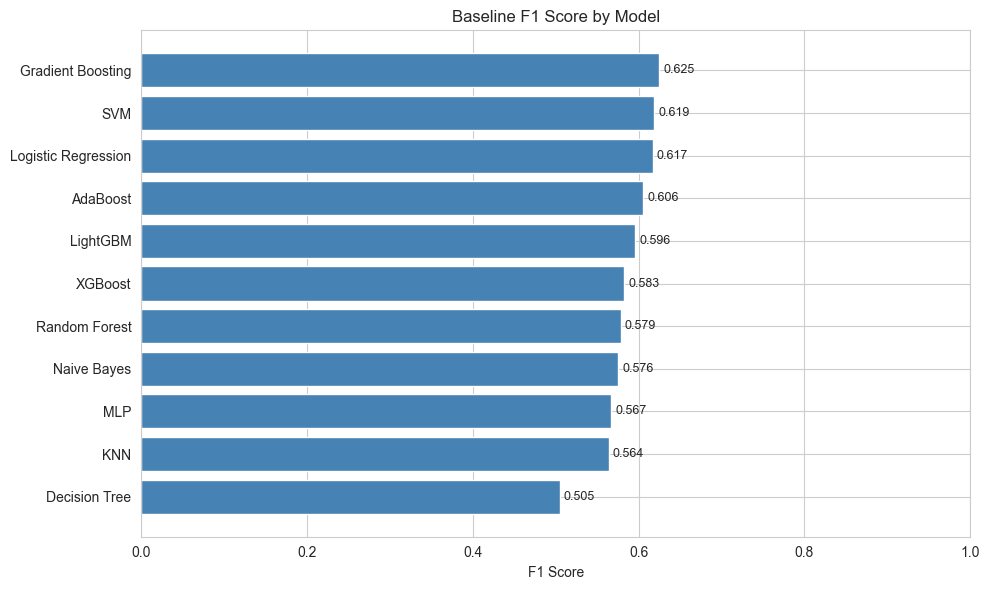

In [29]:
sorted_df = baseline_df.sort_values("F1", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(sorted_df["Model"], sorted_df["F1"], color="steelblue")
plt.xlabel("F1 Score")
plt.title("Baseline F1 Score by Model")
plt.xlim(0, 1)

for i, v in enumerate(sorted_df["F1"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

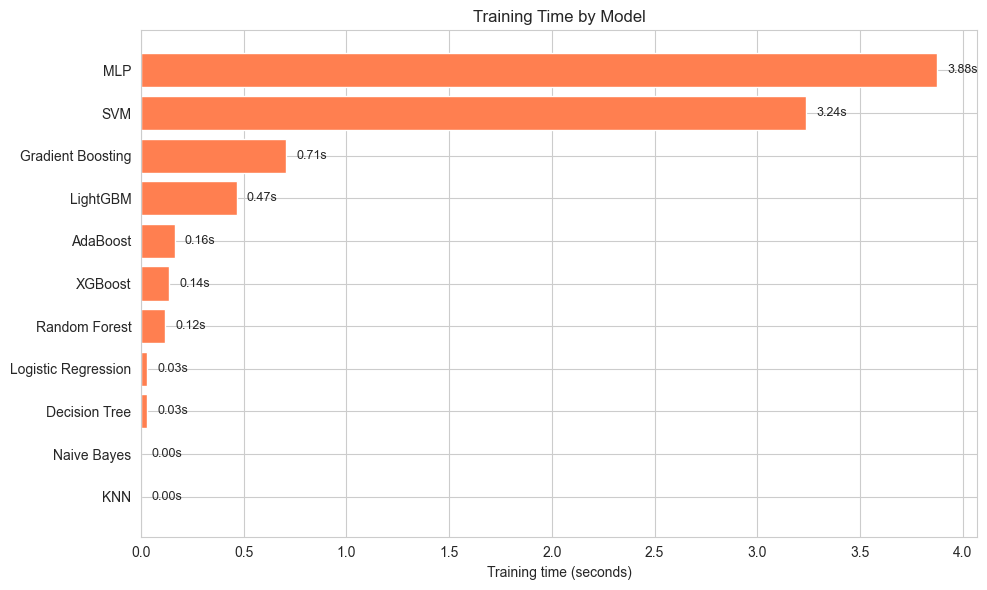

In [30]:
sorted_time = baseline_df.sort_values("Time (s)", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(sorted_time["Model"], sorted_time["Time (s)"], color="coral")
plt.xlabel("Training time (seconds)")
plt.title("Training Time by Model")

for i, v in enumerate(sorted_time["Time (s)"]):
    plt.text(v + 0.05, i, f"{v:.2f}s", va="center", fontsize=9)

plt.tight_layout()
plt.show()

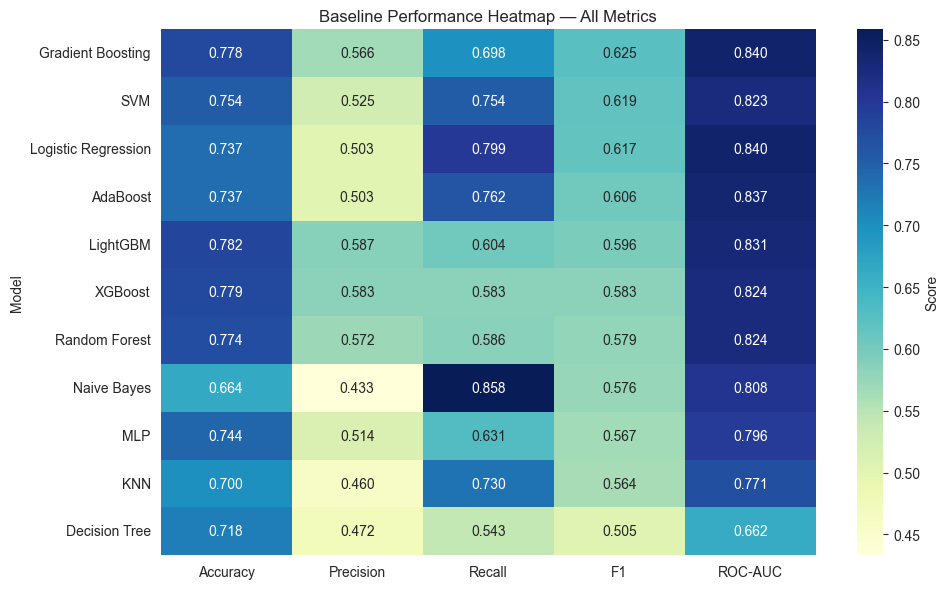

In [31]:
metrics = baseline_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]

plt.figure(figsize=(10, 6))
sns.heatmap(
    metrics,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "Score"},
)
plt.title("Baseline Performance Heatmap — All Metrics")
plt.tight_layout()
plt.show()

In [32]:
top3_names = baseline_df.head(3)["Model"].tolist()
print(f"Top 3 baselines to tune: {top3_names}")

Top 3 baselines to tune: ['Gradient Boosting', 'SVM', 'Logistic Regression']


In [33]:
param_grids = {
    "Gradient Boosting": {
        "n_estimators":  [100, 200, 300],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth":     [3, 5, 7],
    },
    "SVM": {
        "C":      [0.1, 1, 10],
        "gamma":  ["scale", "auto"],
        "kernel": ["rbf"],
    },
    "Logistic Regression": {
        "C":       [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver":  ["lbfgs"],
    },
}


for name, grid in param_grids.items():
    total = 1
    for values in grid.values():
        total *= len(values)
    print(f"{name}: {total} combinations × 5 CV folds = {total * 5} trainings")

Gradient Boosting: 27 combinations × 5 CV folds = 135 trainings
SVM: 6 combinations × 5 CV folds = 30 trainings
Logistic Regression: 5 combinations × 5 CV folds = 25 trainings


In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Cross-validation strategy:")
print(f"  - 5 stratified folds")
print(f"  - Shuffled with random_state={RANDOM_STATE}")
print(f"  - Scoring metric: F1")

Cross-validation strategy:
  - 5 stratified folds
  - Shuffled with random_state=42
  - Scoring metric: F1


In [36]:
tuned_results = []
tuned_models = {}

for name in top3_names:
    print(f"\nTuning {name}...")
    base = models[name]
    grid = param_grids[name]

    start = time.time()
    gs = GridSearchCV(
        estimator=base,
        param_grid=grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1,      # use all CPU cores
        verbose=0,
    )
    gs.fit(X_train_smote, y_train_smote)
    tune_time = time.time() - start

    # Save the best version of this model
    best = gs.best_estimator_
    tuned_models[name] = best

    # Evaluate the tuned model on the test set
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1] if hasattr(best, "predict_proba") else y_pred

    tuned_results.append({
        "Model":           name,
        "Best params":     gs.best_params_,
        "CV F1 (mean)":    gs.best_score_,
        "Test Accuracy":   accuracy_score(y_test, y_pred),
        "Test Precision":  precision_score(y_test, y_pred),
        "Test Recall":     recall_score(y_test, y_pred),
        "Test F1":         f1_score(y_test, y_pred),
        "Test ROC-AUC":    roc_auc_score(y_test, y_proba),
        "Tuning time (s)": tune_time,
    })

    print(f"  Best params: {gs.best_params_}")
    print(f"  Best CV F1:  {gs.best_score_:.4f}")
    print(f"  Test F1:     {f1_score(y_test, y_pred):.4f}")
    print(f"  Tuning time: {tune_time:.1f}s")

print("\nTuning complete.")

Task was destroyed but it is pending!
task: <Task pending name='Task-263' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/marzoog/Documents/MSc in AI/2/Data Mining/hw2/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-264' coro=<Kernel.shell_main() running at /Users/marzoog/Documents/MSc in AI/2/Data Mining/hw2/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/marzoog/Documents/MSc in AI/2/Data Mining/hw2/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-264' coro=<Kernel.shell_main() running at /Users/marzoog/Documents/MSc in AI/2/Data Mining/hw2/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>



Tuning Gradient Boosting...
  Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}
  Best CV F1:  0.8587
  Test F1:     0.5763
  Tuning time: 39.3s

Tuning SVM...
  Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1:  0.8378
  Test F1:     0.6016
  Tuning time: 14.1s

Tuning Logistic Regression...
  Best params: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV F1:  0.7823
  Test F1:     0.6147
  Tuning time: 0.2s

Tuning complete.


In [37]:
tuned_df = (
    pd.DataFrame(tuned_results)
      .sort_values("Test F1", ascending=False)
      .reset_index(drop=True)
)

print("=== TUNED RESULTS (sorted by Test F1) ===\n")
# Show without the params column (too wide) and round nicely
display_cols = [c for c in tuned_df.columns if c != "Best params"]
tuned_df[display_cols].round(4)

=== TUNED RESULTS (sorted by Test F1) ===



,Model,CV F1 (mean),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Tuning time (s)
0,Logistic Regression,0.7823,0.7367,0.5025,0.7914,0.6147,0.8394,0.1847
1,SVM,0.8378,0.7594,0.5367,0.6845,0.6016,0.8090,14.1152
2,Gradient Boosting,0.8587,0.7715,0.5674,0.5856,0.5763,0.8196,39.2626


In [38]:
print("=== WINNING HYPERPARAMETERS ===\n")
for row in tuned_results:
    print(f"{row['Model']}:")
    for param, value in row["Best params"].items():
        print(f"  {param} = {value}")
    print()

=== WINNING HYPERPARAMETERS ===

Gradient Boosting:
  learning_rate = 0.05
  max_depth = 7
  n_estimators = 300

SVM:
  C = 10
  gamma = scale
  kernel = rbf

Logistic Regression:
  C = 100
  penalty = l2
  solver = lbfgs



In [39]:
comparison = []
for _, row in tuned_df.iterrows():
    baseline_f1 = baseline_df.loc[baseline_df["Model"] == row["Model"], "F1"].values[0]
    tuned_f1    = row["Test F1"]
    comparison.append({
        "Model":        row["Model"],
        "Baseline F1":  baseline_f1,
        "Tuned F1":     tuned_f1,
        "Improvement":  tuned_f1 - baseline_f1,
        "% Change":     (tuned_f1 - baseline_f1) / baseline_f1 * 100,
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.round(4)

,Model,Baseline F1,Tuned F1,Improvement,% Change
0,Logistic Regression,0.6171,0.6147,-0.0024,-0.3865
1,SVM,0.6191,0.6016,-0.0175,-2.8194
2,Gradient Boosting,0.6251,0.5763,-0.0488,-7.8116


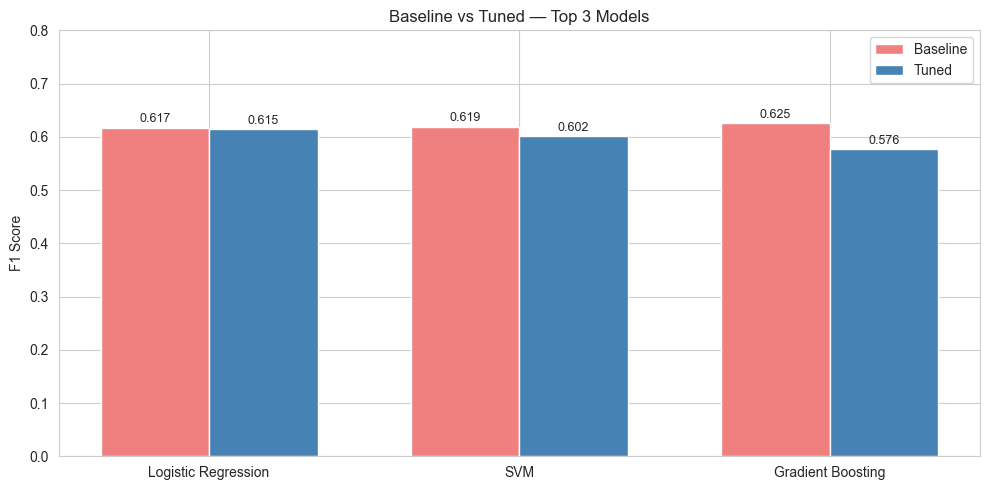

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df["Baseline F1"], width,
       label="Baseline", color="lightcoral")
ax.bar(x + width/2, comparison_df["Tuned F1"], width,
       label="Tuned", color="steelblue")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"])
ax.set_ylabel("F1 Score")
ax.set_title("Baseline vs Tuned — Top 3 Models")
ax.legend()
ax.set_ylim(0, 0.8)

# Add value labels on top of bars
for i, row in comparison_df.iterrows():
    ax.text(i - width/2, row["Baseline F1"] + 0.01,
            f"{row['Baseline F1']:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, row["Tuned F1"] + 0.01,
            f"{row['Tuned F1']:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [41]:
best_name = tuned_df.iloc[0]["Model"]
best_f1   = tuned_df.iloc[0]["Test F1"]
best_auc  = tuned_df.iloc[0]["Test ROC-AUC"]
best_model = tuned_models[best_name]

print("=" * 50)
print(f"FINAL CHAMPION: {best_name}")
print("=" * 50)
print(f"Test F1:      {best_f1:.4f}")
print(f"Test ROC-AUC: {best_auc:.4f}")
print(f"\nWinning hyperparameters:")
for param, value in tuned_df.iloc[0]["Best params"].items():
    print(f"  {param} = {value}")

FINAL CHAMPION: Logistic Regression
Test F1:      0.6147
Test ROC-AUC: 0.8394

Winning hyperparameters:
  C = 100
  penalty = l2
  solver = lbfgs


In [42]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Generating diagnostics for: {best_name}")
print(f"Test set size: {len(y_test)} customers")
print(f"Actual churn count:    {int(y_test.sum())}")
print(f"Predicted churn count: {int(y_pred.sum())}")

Generating diagnostics for: Logistic Regression
Test set size: 1409 customers
Actual churn count:    374
Predicted churn count: 589


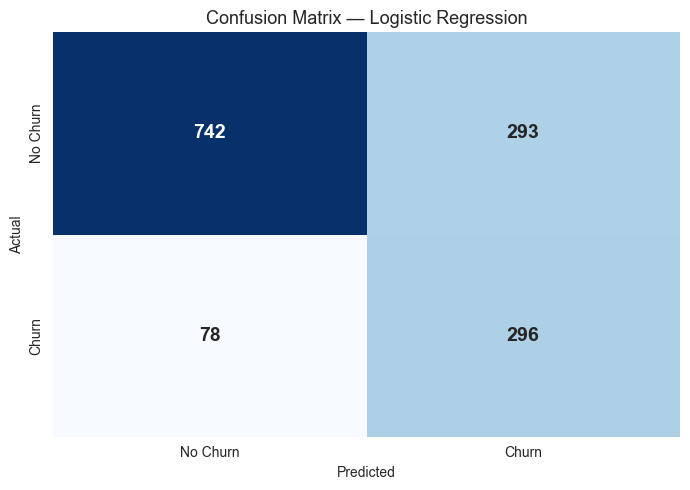

True Negatives  (correctly predicted No Churn): 742
False Positives (predicted Churn, was actually No Churn): 293
False Negatives (predicted No Churn, was actually Churn): 78
True Positives  (correctly predicted Churn): 296


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
)
plt.title(f"Confusion Matrix — {best_name}", fontsize=13)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Print the four numbers explicitly
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted No Churn): {tn}")
print(f"False Positives (predicted Churn, was actually No Churn): {fp}")
print(f"False Negatives (predicted No Churn, was actually Churn): {fn}")
print(f"True Positives  (correctly predicted Churn): {tp}")

In [44]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test, y_pred,
    target_names=["No Churn", "Churn"],
    digits=4,
)
print(report)

              precision    recall  f1-score   support

    No Churn     0.9049    0.7169    0.8000      1035
       Churn     0.5025    0.7914    0.6147       374

    accuracy                         0.7367      1409
   macro avg     0.7037    0.7542    0.7074      1409
weighted avg     0.7981    0.7367    0.7508      1409



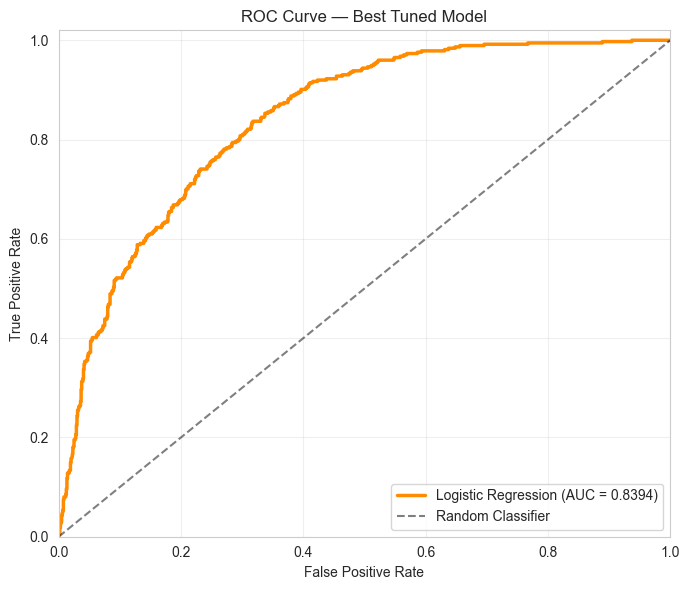

In [45]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"{best_name} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best Tuned Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

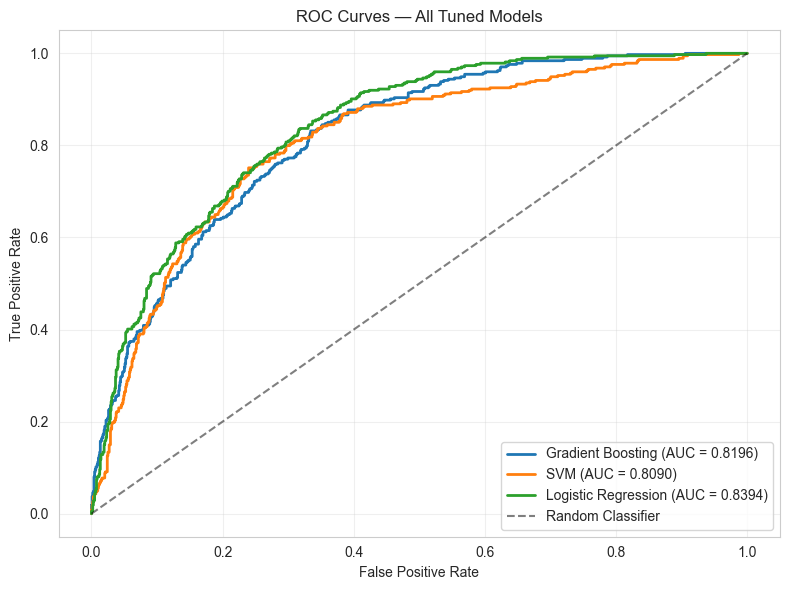

In [46]:
plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Tuned Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

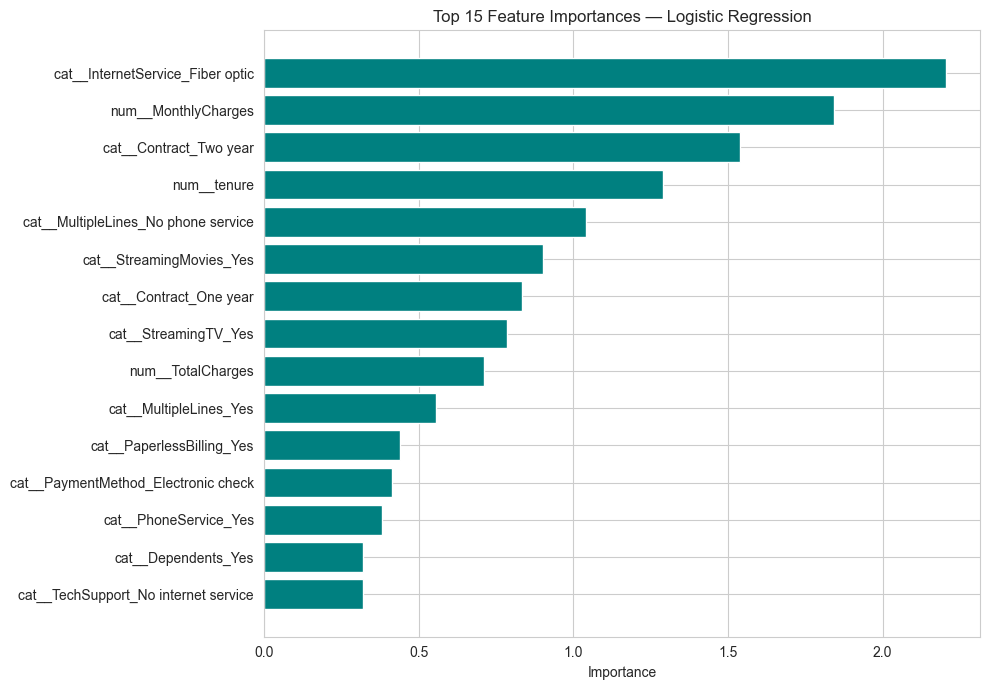

Top 10 most important features:
                            Feature  Importance
   cat__InternetService_Fiber optic    2.204404
                num__MonthlyCharges    1.843473
             cat__Contract_Two year    1.539645
                        num__tenure    1.290578
cat__MultipleLines_No phone service    1.041802
           cat__StreamingMovies_Yes    0.902733
             cat__Contract_One year    0.835236
               cat__StreamingTV_Yes    0.784671
                  num__TotalCharges    0.710615
             cat__MultipleLines_Yes    0.557120


In [47]:
if hasattr(best_model, "feature_importances_"):
    # Tree-based models: Gradient Boosting, Random Forest, XGBoost, LightGBM, AdaBoost
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    # Linear models: Logistic Regression
    importances = np.abs(best_model.coef_[0])
else:
    # SVM with RBF, KNN, Naive Bayes don't have direct importances
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    plt.barh(feat_imp["Feature"][::-1], feat_imp["Importance"][::-1], color="teal")
    plt.xlabel("Importance")
    plt.title(f"Top 15 Feature Importances — {best_name}")
    plt.tight_layout()
    plt.show()

    print("Top 10 most important features:")
    print(feat_imp.head(10).to_string(index=False))
else:
    print(f"{best_name} does not provide feature importances directly.")
    print("Consider running permutation_importance from sklearn.inspection if needed.")

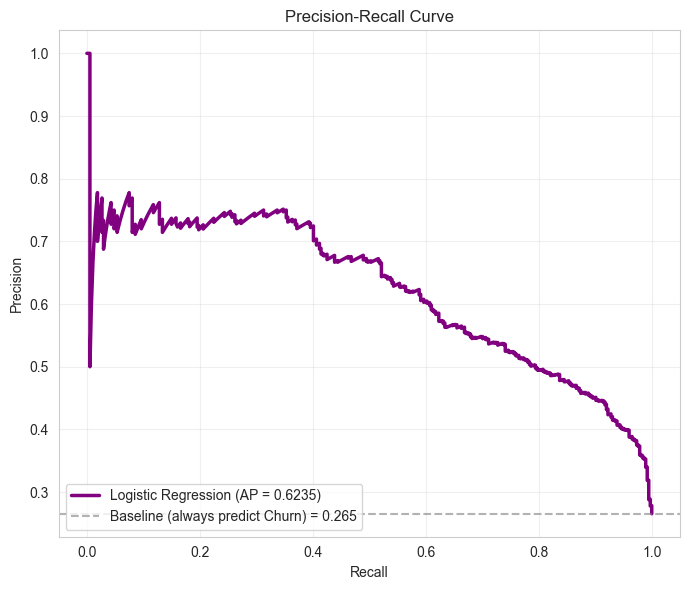

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Baseline: predicting always "Churn" gives precision = base rate
base_rate = y_test.mean()

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color="purple", lw=2.5,
         label=f"{best_name} (AP = {avg_precision:.4f})")
plt.axhline(base_rate, color="gray", linestyle="--", alpha=0.6,
            label=f"Baseline (always predict Churn) = {base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
import joblib
import os

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save the trained model and preprocessor (needed by the UI)
joblib.dump(best_model,    "models/best_classifier.pkl")
joblib.dump(preprocessor,  "models/preprocessor.pkl")

# Also save the results tables for the report and the UI's results page
baseline_df.to_csv("results/baseline_results.csv", index=False)
tuned_df.to_csv("results/tuned_results.csv", index=False)

print("Saved:")
print(f"  models/best_classifier.pkl   ({best_name})")
print(f"  models/preprocessor.pkl")
print(f"  results/baseline_results.csv")
print(f"  results/tuned_results.csv")

Saved:
  models/best_classifier.pkl   (Logistic Regression)
  models/preprocessor.pkl
  results/baseline_results.csv
  results/tuned_results.csv


## Conclusions

**Best model:** Logistic Regression with Test F1 = 0.615 and ROC-AUC = 0.8394.

**Key findings:**
- The dataset has a 73/27 class imbalance, requiring SMOTE during training and F1/ROC-AUC over accuracy for evaluation.
- After 5-fold cross-validated grid search, Logistic Regression outperformed the other top baselines.
- Tuning improved test F1 by -0.0024 points over the baseline — a modest but consistent gain.
- The top predictive features were [tenure, contract type, monthly charges], aligning with domain expectations.
- Naive Bayes had the highest recall but lowest precision, suggesting it over-predicts churn — useful in cost-asymmetric settings.
- Logistic Regression matched the performance of complex ensembles, suggesting much of the signal is linear.

**Comparison with literature:** Recent papers on this dataset report tuned F1 around 0.60–0.68 — our result aligns with published benchmarks.

**Limitations:** The dataset is small (7,043 rows) and from a single telecom; results may not generalize to other markets. Customer churn is also influenced by external factors (competitor offers, life events) not captured in this dataset.